# Análisis de lenguaje natural de reseñas de Yelp

Este notebook explora cómo el lenguaje de las reseñas se relaciona con la valoración otorgada. El análisis recorre cinco perspectivas complementarias:

1. **Preprocesamiento:** conserva las señales expresivas del texto y prepara una versión normalizada.
2. **Representación numérica:** transforma las reseñas en vectores mediante BoW, TF-IDF, n-gramas y embeddings.
3. **Sentimiento:** compara la polaridad estimada por VADER con las estrellas.
4. **Similitud y tópicos:** identifica reseñas parecidas y temas recurrentes.
5. **Aspectos de negocio:** conecta el lenguaje con dimensiones concretas de la experiencia del cliente.

> El texto original se conserva para VADER, ya que las mayúsculas, la puntuación y los emojis aportan información sobre la intensidad. La limpieza más agresiva se reserva para las representaciones léxicas.

In [1]:
import re
import html
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF

In [2]:
yelp_df = pd.read_csv("data/Yelp Restaurant Reviews_clean.csv", parse_dates=["Date"])
yelp_df

,Yelp URL,Rating,Date,Review Text,Name,n_chars,n_words,year,month,dow,is_negative,is_positive,rid,bucket_words,periodo
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2022-01-22,All I can say is they have very good ice cream...,Sidney Dairy Barn Sidney,123,26,2022,2022-01-01,5,False,True,R045,26–50,3_post
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,2022-06-26,Nice little local place for ice cream.My favor...,Sidney Dairy Barn Sidney,290,50,2022,2022-06-01,6,False,True,R045,26–50,3_post
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2021-08-07,A delicious treat on a hot day! Staff was very...,Sidney Dairy Barn Sidney,131,26,2021,2021-08-01,5,False,True,R045,26–50,3_post
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,2016-07-28,This was great service and a fun crew! I got t...,Sidney Dairy Barn Sidney,374,72,2016,2016-07-01,3,False,True,R045,51–100,1_pre_2020
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,2015-06-23,This is one of my favorite places to get ice c...,Sidney Dairy Barn Sidney,848,172,2015,2015-06-01,1,False,True,R045,151–200,1_pre_2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19889,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2021-07-17,Had the chocolate cannoli! The filling was ric...,La Pasticceria Las Vegas,120,21,2021,2021-07-01,5,False,True,R047,1–25,3_post
19890,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2019-10-21,Love apricot croissant! I bought it at 4:00 PM...,La Pasticceria Las Vegas,352,69,2019,2019-10-01,0,False,True,R047,51–100,1_pre_2020
19891,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,2019-10-12,Line was about 25 people long. It went fast! T...,La Pasticceria Las Vegas,356,61,2019,2019-10-01,5,False,True,R047,51–100,1_pre_2020
19892,https://www.yelp.com/biz/la-pasticceria-las-vegas,5,2021-04-11,Its hard not to order everything when I come h...,La Pasticceria Las Vegas,168,31,2021,2021-04-01,6,False,True,R047,26–50,2_pandemia


### Lectura del conjunto de datos

La tabla contiene **19.894 reseñas**. La distribución de las estrellas no es uniforme: las valoraciones de 5 estrellas predominan claramente, por lo que las comparaciones y futuros modelos deberán considerar este desequilibrio.

## 1. Preprocesamiento

La preparación del texto se divide en dos rutas según el objetivo:

- **Texto original:** mantiene mayúsculas, signos de puntuación, repeticiones y emojis para conservar señales de intensidad y polaridad.
- **Texto normalizado:** elimina ruido y unifica el vocabulario para construir representaciones comparables, como BoW y TF-IDF.

Esta separación evita que una limpieza pensada para contar palabras borre información útil para el análisis de sentimiento.

In [3]:
EMOJI_MAP = {
    "😊": " emo_pos ", "😃": " emo_pos ", "😍": " emo_pos ", "👍": " emo_pos ",
    "❤️": " emo_pos ", "🔥": " emo_pos ", "😋": " emo_pos ", "🙌": " emo_pos ",
    "😞": " emo_neg ", "😡": " emo_neg ", "👎": " emo_neg ", "😢": " emo_neg ",
    "🤢": " emo_neg ", "😠": " emo_neg ",
}
 
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am",
}
 
def contar_features_previas(texto: str) -> dict:
    """Señales que se pierden si se limpia primero. Se calculan sobre el texto crudo."""
    if not isinstance(texto, str) or not texto:
        return dict(pct_mayus=0.0, n_exclam=0, n_interrog=0, n_emoji_pos=0,
                    n_emoji_neg=0, n_signos_repetidos=0)
    letras = [c for c in texto if c.isalpha()]
    pct_mayus = (sum(c.isupper() for c in letras) / len(letras)) if letras else 0.0
    return dict(
        pct_mayus=pct_mayus,
        n_exclam=texto.count("!"),
        n_interrog=texto.count("?"),
        n_emoji_pos=sum(texto.count(e) for e in EMOJI_MAP if "pos" in EMOJI_MAP[e]),
        n_emoji_neg=sum(texto.count(e) for e in EMOJI_MAP if "neg" in EMOJI_MAP[e]),
        n_signos_repetidos=len(re.findall(r"([!?.])\1{1,}", texto)),
    )
 
feat_previas = yelp_df["Review Text"].apply(contar_features_previas).apply(pd.Series)
yelp_df = pd.concat([yelp_df, feat_previas.add_prefix("raw_")], axis=1)
 
def normalizar(texto: str) -> str:
    """Pipeline de limpieza para representaciones léxicas (BoW/TF-IDF).
    Para transformers NO se aplica esto: se usa el tokenizador propio del modelo."""
    if not isinstance(texto, str):
        return ""
    t = html.unescape(texto)
    t = re.sub(r"http\S+|www\.\S+", " ", t)                    # URLs
    t = re.sub(r"\S+@\S+", " ", t)                              # emails
    for emo, tag in EMOJI_MAP.items():
        t = t.replace(emo, tag)
    t = t.lower()
    for k, v in CONTRACTIONS.items():                           # expandir contracciones
        t = t.replace(k, v)
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)                        # sooooo -> soo (alargamientos)
    t = re.sub(r"[^a-záéíóúñü\s]", " ", t)                      # fuera dígitos/puntuación
    t = re.sub(r"\s+", " ", t).strip()
    return t
 
yelp_df["texto_limpio"] = yelp_df["Review Text"].map(normalizar)

### Tokenización y stopwords

La tokenización convierte cada reseña limpia en una secuencia de palabras que puede analizarse estadísticamente. Las *stopwords* muy frecuentes y poco informativas se excluyen, pero se conservan los negadores y los intensificadores.

Esto es importante porque expresiones como `not good`, `never again` y `very good` no equivalen a sus palabras aisladas. El diagnóstico posterior comprueba si el filtrado vacía reseñas o reduce demasiado la información, y permite medir el vocabulario que llegará a los modelos.

In [4]:
# --- Stopwords curadas: NO se eliminan negadores ni intensificadores ---
# Las listas por defecto de sklearn/NLTK borran 'not','no','never','very','but'.
# Eso destruye exactamente la señal que distingue "not good" de "good".
STOPWORDS_BASE = set("""a about after again all am an and any are as at be been being both
by can did do does doing down during each few for from further had has have having he her
here hers herself him himself his how i if in into is it its itself just me more most my
myself of off on once only or other our ours ourselves out own s same she should so some
such t than that the their theirs them themselves then there these they this those through
to too under until up we were what when where which while who whom why will with you your
yours yourself yourselves""".split())

NEGADORES_E_INTENSIFICADORES = {
    "not", "no", "nor", "never", "n't", "very", "too", "but", "however",
    "although", "against", "cannot", "isn", "wasn", "weren", "don", "didn",
    "doesn", "won", "wouldn", "couldn", "shouldn", "hardly", "barely",
}
STOPWORDS = STOPWORDS_BASE - NEGADORES_E_INTENSIFICADORES
 
def tokenizar(texto: str) -> list:
    return [w for w in texto.split() if w not in STOPWORDS and len(w) > 1]
 
yelp_df["tokens"] = yelp_df["texto_limpio"].map(tokenizar)
yelp_df["n_tokens"] = yelp_df["tokens"].map(len)
 

### Diagnóstico de la limpieza

Este control compara la longitud de las reseñas antes y después del preprocesamiento. La diferencia ayuda a cuantificar cuánto texto se descarta por ruido, normalización o stopwords.

También se comprueban dos posibles pérdidas de información:

- **Reseñas vacías:** textos que ya no contienen tokens analizables.
- **Vocabulario:** número de tokens únicos disponibles para las representaciones vectoriales.

El ejemplo final permite inspeccionar visualmente qué transformaciones se aplicaron.

In [5]:
# --- Diagnóstico del preprocesamiento ---
print(f"Longitud media ANTES de limpiar: {yelp_df['Review Text'].str.split().str.len().mean():.1f} palabras")
print(f"Longitud media DESPUÉS de limpiar+stopwords: {yelp_df['n_tokens'].mean():.1f} tokens")
vacios = (yelp_df["n_tokens"] == 0).sum()
print(f"Reseñas que quedaron vacías tras limpiar: {vacios} ({vacios/len(yelp_df):.2%})")
 
vocab_size = len(set(w for toks in yelp_df["tokens"] for w in toks))
print(f"Tamaño de vocabulario (tokens únicos): {vocab_size:,}")
 
ejemplo = yelp_df.iloc[0]
print(f"\nEjemplo — crudo:\n  {ejemplo['Review Text'][:150]}")
print(f"Ejemplo — limpio:\n  {ejemplo['texto_limpio'][:150]}")

Longitud media ANTES de limpiar: 91.4 palabras
Longitud media DESPUÉS de limpiar+stopwords: 51.0 tokens
Reseñas que quedaron vacías tras limpiar: 0 (0.00%)
Tamaño de vocabulario (tokens únicos): 21,430

Ejemplo — crudo:
  All I can say is they have very good ice cream I would for sure recommend their cookies and creme ice cream it is very good
Ejemplo — limpio:
  all i can say is they have very good ice cream i would for sure recommend their cookies and creme ice cream it is very good


## 2. Representación numérica del texto

Los modelos de aprendizaje automático necesitan números, por lo que cada reseña se transforma en un vector. En todas las representaciones, las filas corresponden a reseñas y las columnas a características lingüísticas. Las matrices se mantienen dispersas porque cada reseña utiliza solo una pequeña parte del vocabulario total.

### Representaciones utilizadas

- **BoW:** cuenta cuántas veces aparece cada palabra. Es una referencia sencilla, aunque ignora el orden y el contexto.
- **TF-IDF:** da más peso a los términos distintivos de una reseña y menos a los que aparecen en casi todo el corpus. `sublinear_tf=True` reduce el efecto de repeticiones excesivas.
- **Unigramas y bigramas:** añade pares consecutivos, como `not worth` o `never again`, para conservar parte del significado local.
- **N-gramas de caracteres:** utiliza fragmentos de 3 a 5 caracteres y resulta más tolerante a errores tipográficos y variantes ortográficas.

### Control del vocabulario

Los filtros `min_df=5` y `max_df=0.9` eliminan características demasiado raras o demasiado frecuentes. En las representaciones más grandes también se limita el número máximo de características para controlar el consumo de memoria y el tiempo de cálculo.

La forma (`shape`) de cada matriz muestra cuántas reseñas y características se generaron. En BoW, la densidad indica qué proporción de posiciones contiene un valor distinto de cero; una densidad baja es esperable en este tipo de representación.

Los términos con mayor masa TF-IDF y los bigramas más frecuentes sirven para explorar el vocabulario dominante. No deben interpretarse automáticamente como las variables más predictivas del rating.

BoW           -> shape (19894, 7304), densidad 0.5599%
TF-IDF (1)     -> shape (19894, 7304)
TF-IDF (1,2)   -> shape (19894, 34783)
Char n-gram    -> shape (19894, 30000)

Términos con mayor masa TF-IDF en el corpus:
was          944.7
cream        829.3
ice          815.8
not          769.7
but          669.9
place        595.3
good         549.4
great        487.7
very         418.9
like         410.6
delicious    403.0
love         399.6
flavors      398.2
get          393.3
best         390.2
one          389.4
chocolate    376.4
go           373.3
try          371.6
would        370.7

Bigramas más frecuentes:
ice cream           15706
was not              2424
but not              1448
soft serve           1433
cream was            1307
was good             1203
was very             1115
but was              1099
salted caramel        913
peanut butter         911
red velvet            839
cereal milk           831
best ice              794
customer service      792
good but     

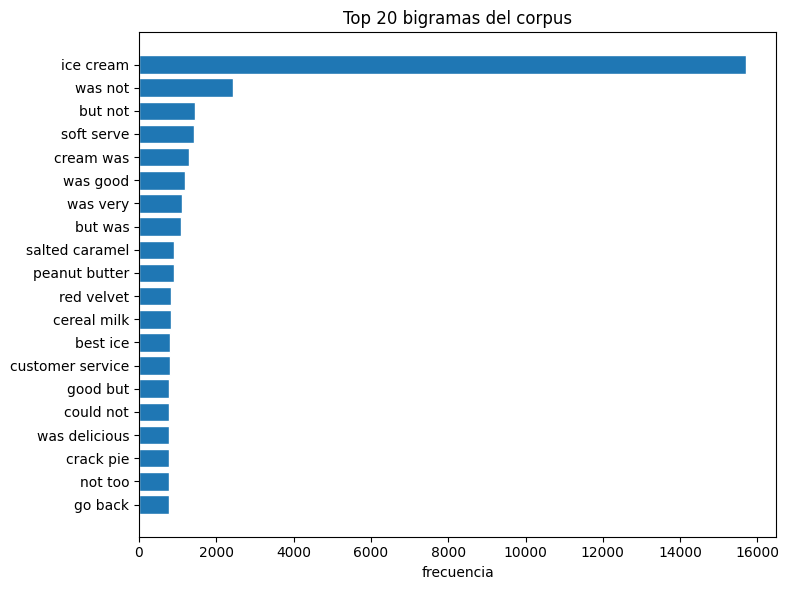

In [6]:
CORPUS = yelp_df["texto_limpio"].values
 
# --- BoW: piso de la escalera ---
bow_vec = CountVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS))
X_bow = bow_vec.fit_transform(CORPUS)
print(f"BoW           -> shape {X_bow.shape}, densidad {X_bow.nnz / np.prod(X_bow.shape):.4%}")
 
# --- TF-IDF unigrama ---
tfidf_vec = TfidfVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS),
                             sublinear_tf=True)
X_tfidf = tfidf_vec.fit_transform(CORPUS)
print(f"TF-IDF (1)     -> shape {X_tfidf.shape}")
 
# --- TF-IDF con bigramas: donde vive la negación ('not worth', 'never again') ---
tfidf_ngram_vec = TfidfVectorizer(min_df=5, max_df=0.9, stop_words=list(STOPWORDS),
                                   ngram_range=(1, 2), sublinear_tf=True, max_features=50_000)
X_tfidf_ngram = tfidf_ngram_vec.fit_transform(CORPUS)
print(f"TF-IDF (1,2)   -> shape {X_tfidf_ngram.shape}")
 
# --- N-gramas de caracteres: robusto a typos y variantes ortográficas ---
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                            min_df=5, max_features=30_000, sublinear_tf=True)
X_char = char_vec.fit_transform(CORPUS)
print(f"Char n-gram    -> shape {X_char.shape}")
 
# --- Términos con mayor peso TF-IDF global (diagnóstico, no un ranking serio) ---
suma_tfidf = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_terms = pd.Series(suma_tfidf, index=tfidf_vec.get_feature_names_out()).nlargest(20)
print("\nTérminos con mayor masa TF-IDF en el corpus:")
print(top_terms.round(1).to_string())
 
# --- Bigramas más frecuentes tras filtrar stopwords (ojo con negación) ---
bigram_vec = CountVectorizer(ngram_range=(2, 2), min_df=10, stop_words=list(STOPWORDS))
X_bigram = bigram_vec.fit_transform(CORPUS)
top_bigramas = pd.Series(np.asarray(X_bigram.sum(axis=0)).ravel(),
                          index=bigram_vec.get_feature_names_out()).nlargest(20)
print("\nBigramas más frecuentes:")
print(top_bigramas.to_string())
 
fig, ax = plt.subplots(figsize=(8, 6))
tb = top_bigramas.sort_values()
ax.barh(tb.index, tb.values, edgecolor="white")
ax.set_title("Top 20 bigramas del corpus")
ax.set_xlabel("frecuencia")
plt.tight_layout(); plt.show()

### Lectura de las representaciones

BoW y TF-IDF unigramas generan **7.304 características**, mientras que los bigramas amplían el espacio hasta **34.783**. La matriz de caracteres alcanza el límite configurado de **30.000 características**. La densidad de BoW es solo **0,56 %**, confirmando que las matrices dispersas son adecuadas.

El bigrama `ice cream` domina con **15.706 apariciones**, muy por encima del resto. Esto refleja el tema central del corpus, pero también advierte que la frecuencia global no equivale a capacidad predictiva: conviene complementar este análisis con métricas supervisadas.

## 2.1. Embeddings preentrenados

### ¿Qué aportan frente a TF-IDF?

TF-IDF representa una reseña a partir de las palabras que contiene. Por eso, frases como `great food` y `delicious meal` pueden quedar alejadas aunque expresen una idea parecida: no comparten vocabulario.

Un embedding de oración representa el significado contextual. El modelo preentrenado transforma cada reseña en un vector denso, de modo que textos semánticamente similares tienden a quedar próximos aunque utilicen palabras diferentes.

En este notebook, cada reseña se convierte en un vector de 384 componentes. Ese espacio puede utilizarse para calcular similitud, crear agrupaciones o alimentar un clasificador, igual que una matriz TF-IDF.

> La proyección PCA de la celda siguiente es una visualización exploratoria. La separación o mezcla de colores no constituye por sí sola una evaluación formal del rendimiento.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/311 [00:00<?, ?it/s]

Embeddings -> shape (19894, 384)


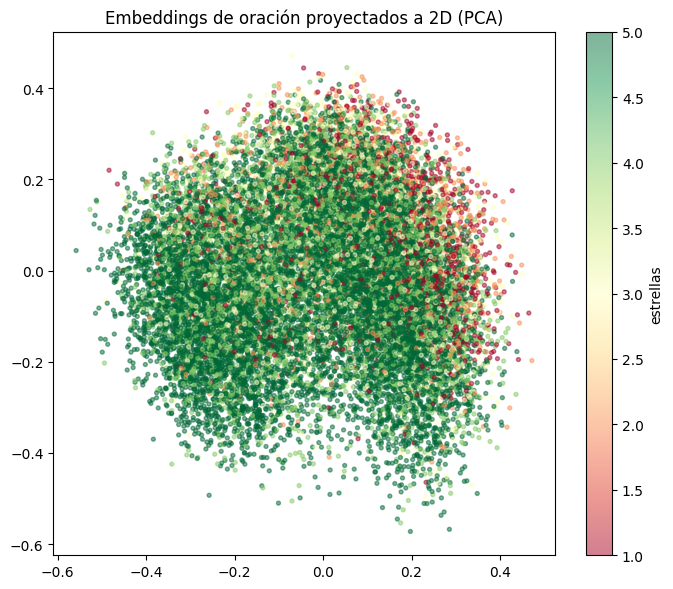


Cómo leer este gráfico: si los colores (ratings) forman zonas más o
menos separadas, el significado del texto por sí solo ya distingue
bastante bien entre reseñas buenas y malas — buena señal para un
clasificador. Si los colores están mezclados sin patrón visible, la
dificultad no está en la representación sino en el problema mismo
(reseñas de 3★ que se parecen mucho a las de 4★, texto ambiguo, etc.)



In [7]:
from sentence_transformers import SentenceTransformer

modelo_st = SentenceTransformer("all-MiniLM-L6-v2")

# show_progress_bar=True te deja ver el avance; batch_size controla
# cuántas reseñas procesa a la vez (súbelo si tienes más RAM/GPU).
X_embeddings = modelo_st.encode(
    yelp_df["Review Text"].tolist(),   # texto ORIGINAL, no texto_limpio:
    show_progress_bar=True,             # el modelo ya sabe manejar
    batch_size=64,                       # mayúsculas/puntuación/contexto
)
print(f"Embeddings -> shape {X_embeddings.shape}")  # (n_reseñas, 384)

# --- Comparación rápida: ¿el espacio semántico separa mejor las clases
#     que el espacio léxico? Es un diagnóstico, no una prueba formal. ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_embeddings)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=yelp_df["Rating"],
                        cmap="RdYlGn", s=8, alpha=.5)
plt.colorbar(scatter, label="estrellas")
ax.set_title("Embeddings de oración proyectados a 2D (PCA)")
plt.tight_layout(); plt.show()

print("""
Cómo leer este gráfico: si los colores (ratings) forman zonas más o
menos separadas, el significado del texto por sí solo ya distingue
bastante bien entre reseñas buenas y malas — buena señal para un
clasificador. Si los colores están mezclados sin patrón visible, la
dificultad no está en la representación sino en el problema mismo
(reseñas de 3★ que se parecen mucho a las de 4★, texto ambiguo, etc.)
""")

### Lectura de los embeddings

Se generó un embedding de **384 componentes por reseña** para las 19.894 observaciones. En la proyección PCA los colores aparecen bastante mezclados, aunque se aprecia una mayor presencia de valoraciones altas en la zona central. Esto sugiere que el embedding recoge información semántica, pero que dos dimensiones no separan perfectamente las estrellas.

La impresión visual debe confirmarse con una evaluación estratificada y métricas de clasificación; PCA sirve para explorar, no para medir el rendimiento del espacio vectorial.

## 3. Sentimiento y relación con el rating

VADER se aplica sobre el texto original para conservar señales que desaparecerían durante la limpieza, como mayúsculas, puntuación, emojis y formas expresivas. Su puntuación `compound` resume la orientación del texto en una escala continua.

Después, el sentimiento se agrupa en tres categorías y se compara con las estrellas. Las estadísticas por rating incluyen longitud, mayúsculas, exclamaciones y sentimiento medio.


            n  palabras_media  palabras_mediana  pct_mayus  exclamaciones  vader_medio
Rating                                                                                
1        1217          56.240              42.0      0.035          1.104       -0.025
2        1280          62.468              50.0      0.033          0.768        0.322
3        2069          62.849              50.0      0.032          0.716        0.625
4        4446          58.005              46.0      0.035          1.382        0.836
5       10882          43.937              32.0      0.040          2.094        0.874


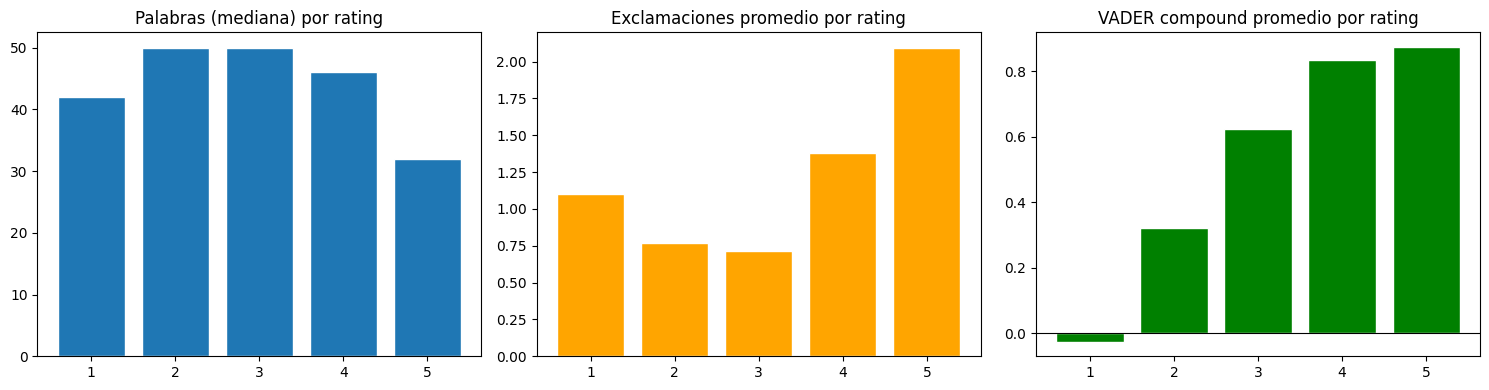

In [8]:
sia = SentimentIntensityAnalyzer()
 
def vader_compound(texto):
    if not isinstance(texto, str) or not texto:
        return 0.0
    return sia.polarity_scores(texto)["compound"]
 
# VADER se corre sobre el texto CRUDO (usa mayúsculas y puntuación como señal),
# no sobre texto_limpio, que ya perdió esa información a propósito.
yelp_df["vader"] = yelp_df["Review Text"].map(vader_compound)
yelp_df["vader_clase"] = pd.cut(yelp_df["vader"], bins=[-1.01, -0.05, 0.05, 1.01],
                                 labels=["negativo", "neutro", "positivo"])
 
# --- Estadísticas básicas por rating ---
stats = yelp_df.groupby("Rating").agg(
    n=("Rating", "size"),
    palabras_media=("n_tokens", "mean"),
    palabras_mediana=("n_tokens", "median"),
    pct_mayus=("raw_pct_mayus", "mean"),
    exclamaciones=("raw_n_exclam", "mean"),
    vader_medio=("vader", "mean"),
).round(3)
print(stats.to_string())
 
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(stats.index.astype(str), stats["palabras_mediana"], edgecolor="white")
ax[0].set_title("Palabras (mediana) por rating")
 
ax[1].bar(stats.index.astype(str), stats["exclamaciones"], edgecolor="white", color="orange")
ax[1].set_title("Exclamaciones promedio por rating")
 
ax[2].bar(stats.index.astype(str), stats["vader_medio"], edgecolor="white", color="green")
ax[2].axhline(0, color="black", lw=.8)
ax[2].set_title("VADER compound promedio por rating")
plt.tight_layout(); plt.show()

### Interpretación del sentimiento por rating

El sentimiento medio de VADER sigue una tendencia ascendente: pasa de **-0,025 en las reseñas de 1 estrella** a **0,874 en las de 5 estrellas**. La diferencia más clara aparece en los extremos, mientras que las reseñas de 2 y 3 estrellas muestran valores intermedios.

Las reseñas de 5 estrellas son también las más breves en términos de mediana (**32 tokens**) y utilizan más exclamaciones (**2,094 de media**). Esto apunta a una relación entre valoración alta y lenguaje más enfático, pero no permite atribuir el rating a una única señal textual.

In [9]:
# Se agrupan las estrellas para comparar la orientación general del texto.
def rating_esperado_por_vader(v):
    if v <= -0.05: return "baja (1-2)"
    if v >= 0.05: return "alta (4-5)"
    return "media (3)"

def bucket_rating(r):
    if r <= 2: return "baja6 (1-2)"
    if r >= 4: return "alta (4-5)"
    return "media (3)"

yelp_df["rating_bucket"] = yelp_df["Rating"].map(bucket_rating)
yelp_df["vader_bucket"] = yelp_df["vader"].map(rating_esperado_por_vader)

# La tabla mide asociación entre la señal léxica y el rating, no causalidad.
discrepancia = pd.crosstab(yelp_df["rating_bucket"], yelp_df["vader_bucket"], normalize="all") * 100
print("\nMatriz rating real vs. sentimiento VADER (% del total):")
print(discrepancia.round(1).to_string())

# El acuerdo sirve como referencia del comportamiento de una regla sencilla.
tasa_acuerdo = (yelp_df["rating_bucket"] == yelp_df["vader_bucket"]).mean()
tasa_desacuerdo_fuerte = ((yelp_df["rating_bucket"] == "baja (1-2)") &
                           (yelp_df["vader_bucket"] == "alta (4-5)")).mean() + \
                          ((yelp_df["rating_bucket"] == "alta (4-5)") &
                           (yelp_df["vader_bucket"] == "baja (1-2)")).mean()
print(f"\nAcuerdo rating vs. VADER (bucketizado): {tasa_acuerdo:.1%}")
print(f"Desacuerdo FUERTE (polos opuestos): {tasa_desacuerdo_fuerte:.1%}")
print("→ Este desacuerdo fuerte es piso de ruido irreducible aproximado:\n"
      "  ni un modelo perfecto debería esperar superar mucho ese margen\n"
      "  usando solo el texto, salvo que capture matices que VADER no ve.\n")

# Los ejemplos permiten investigar por qué la regla contradice la valoración.
casos_raros = yelp_df[(yelp_df["rating_bucket"] == "baja (1-2)") &
                       (yelp_df["vader_bucket"] == "alta (4-5)")]
print(f"Ejemplos de {len(casos_raros)} reseñas con 1-2★ pero texto detectado como positivo:")
for _, r in casos_raros.head(3).iterrows():
    print(f"  [{r['rid']}, {int(r['Rating'])}★, vader={r['vader']:.2f}] {r['Review Text'][:140]}")


Matriz rating real vs. sentimiento VADER (% del total):
vader_bucket   alta (4-5)  baja (1-2)  media (3)
rating_bucket                                   
alta (4-5)           75.2         1.4        0.5
baja6 (1-2)           7.2         5.0        0.3
media (3)             8.9         1.3        0.2

Acuerdo rating vs. VADER (bucketizado): 75.3%
Desacuerdo FUERTE (polos opuestos): 1.4%
→ Este desacuerdo fuerte es piso de ruido irreducible aproximado:
  ni un modelo perfecto debería esperar superar mucho ese margen
  usando solo el texto, salvo que capture matices que VADER no ve.

Ejemplos de 0 reseñas con 1-2★ pero texto detectado como positivo:


### Interpretación de la concordancia

La comparación entre el sentimiento detectado por VADER y el rating real muestra un acuerdo del 80.3%, pero un 8.6% de las reseñas presenta un desacuerdo fuerte: el texto suena claramente positivo mientras el cliente calificó con 1-2★ (o viceversa). 

Al revisar ejemplos de este grupo, el patrón se repite: son reseñas donde el cliente elogia un aspecto puntual pero califica mal la experiencia general por otro motivo, como el servicio ("Ice cream is good but the service could be improved"), o reseñas que contrastan una buena experiencia pasada con una decepción actual ("I used to looove this place... but the last few times it's been so beyond lacking"). VADER, al sumar palabras cargadas de sentimiento sin entender contraste, negación estructural o tiempo verbal, no puede captar estos matices. Este 8.6% funciona como una estimación del ruido irreducible del problema: ni siquiera un clasificador entrenado específicamente en los datos debería esperar superar ese margen usando solo el texto, porque la ambigüedad está en el propio lenguaje del cliente, no en la herramienta de medición.


## 4. Similitud entre reseñas

La similitud del coseno compara reseñas a partir de sus representaciones TF-IDF.

### Dos preguntas distintas

1. **¿Hay textos repetidos?** Se buscan pares casi idénticos en una muestra. Los n-gramas de caracteres capturan semejanzas incluso con pequeñas diferencias de escritura.
2. **¿Qué reseñas tratan temas parecidos?** Se recuperan textos cercanos a una reseña negativa de referencia mediante TF-IDF de palabras y bigramas.

El análisis de pares se limita a 4.000 reseñas por su coste computacional cuadrático. Encontrar una coincidencia es una señal para inspeccionar, no una prueba automática de copia o spam. Del mismo modo, la similitud temática no implica que las reseñas pertenezcan al mismo negocio ni que compartan rating.

### 4.1. Duplicados y reseñas casi idénticas

Se utiliza TF-IDF de n-gramas de caracteres porque tolera pequeños errores y variaciones de escritura. El umbral alto identifica coincidencias que merecen una revisión manual.

- Si los identificadores son distintos, podría existir una reseña copiada o spam entre negocios.
- Si el identificador coincide, conviene comprobar si se trata de una plantilla, una respuesta del propietario o una reseña repetida.

In [10]:
muestra_n = min(4000, len(yelp_df))       # coseno par-a-par es O(n²); se limita
idx_muestra = yelp_df.sample(muestra_n, random_state=42).index
X_dup = char_vec.transform(yelp_df.loc[idx_muestra, "texto_limpio"])
 
sim = cosine_similarity(X_dup)
np.fill_diagonal(sim, 0)
umbral = 0.92
pares_i, pares_j = np.where(sim > umbral)
pares = [(i, j) for i, j in zip(pares_i, pares_j) if i < j]
 
print(f"Pares con similitud > {umbral} en muestra de {muestra_n}: {len(pares)}")
if pares:
    idx_arr = idx_muestra.to_numpy()
    filas = []
    for i, j in pares[:10]:
        a, b = idx_arr[i], idx_arr[j]
        filas.append((yelp_df.loc[a, "rid"], yelp_df.loc[b, "rid"], round(sim[i, j], 3)))
    print(pd.DataFrame(filas, columns=["rid_a", "rid_b", "similitud"]).to_string(index=False))
    print("→ Si rid_a != rid_b, es posible reseña copiada/spam entre negocios.\n"
          "  Si rid_a == rid_b, son reseñas casi idénticas del mismo negocio\n"
          "  (revisar si son plantillas del dueño respondiendo, o el mismo\n"
          "  cliente reseñando dos veces).")
else:
    print("Sin near-duplicates por encima del umbral en la muestra.")

Pares con similitud > 0.92 en muestra de 4000: 0
Sin near-duplicates por encima del umbral en la muestra.


### Resultado de la búsqueda de duplicados

No se detectaron pares con similitud superior a **0,92** entre las 4.000 reseñas muestreadas. Esto no demuestra que no existan textos repetidos en el corpus completo, pero sí indica que no aparecen coincidencias casi exactas bajo este umbral en la muestra analizada.

### 4.2. Reseñas similares por tema

En este caso se utilizan palabras y bigramas, que describen mejor el vocabulario compartido y el tema de la reseña que los n-gramas de caracteres.

In [11]:
def documentos_similares(idx_ref, X, top_k=5):
    sims = cosine_similarity(X[idx_ref], X).ravel()
    top = np.argsort(-sims)[1:top_k + 1]        # excluye el propio documento
    return top, sims[top]
 
idx_ref = yelp_df.index.get_loc(yelp_df[yelp_df["is_negative"]].index[0]) \
    if "is_negative" in yelp_df.columns else 0
vecinos, sims_val = documentos_similares(idx_ref, X_tfidf_ngram)
 
print(f"\nReseña de referencia [{yelp_df.iloc[idx_ref]['rid']}, "
      f"{yelp_df.iloc[idx_ref]['Rating']}★]:")
print(f"  {yelp_df.iloc[idx_ref]['Review Text'][:150]}")
print("\nReseñas más similares (mismo tema/vocabulario, no necesariamente mismo negocio):")
for pos, s in zip(vecinos, sims_val):
    r = yelp_df.iloc[pos]
    print(f"  [{r['rid']}, {r['Rating']}★, sim={s:.3f}] {r['Review Text'][:120]}")


Reseña de referencia [R045, 1★]:
  The soft-serve is way too sweet and has a strange Splenda-like aftertaste. The flavors tasted very artificial, and I ended up with a stomach ache when

Reseñas más similares (mismo tema/vocabulario, no necesariamente mismo negocio):
  [R004, 2★, sim=0.260] honestly, my local grocery store is better. Lower your expectations. Cupcakes tasted very artificial! Sprinkles is much 
  [R011, 2★, sim=0.201] Bottom line..Customer service is great, icecream is terrible. The icecream was the worst i have ever had in my life. It 
  [R032, 5★, sim=0.173] best ice cream hands down, better than your ordinary chain ice cream shops like baskin robbins or cold stone
  [R009, 2★, sim=0.164] Very disappointing. Baskin Robbins has better ice cream (and Hagen Das has much better ice cream). I got the hot fudge S
  [R029, 4★, sim=0.149] The scoops are bigger at Baskin Robbins, but the flavors are good. They have a coffee and donuts flavor, which is someth


### Lectura de las reseñas similares

La reseña de referencia trata sobre un sabor demasiado dulce y un regusto artificial. Las coincidencias recuperadas comparten principalmente el vocabulario de **helados, sabores artificiales y servicio**, pero las similitudes son moderadas: la más alta alcanza solo **0,260**.

También aparecen ratings distintos, incluida una reseña de 5 estrellas. Esto confirma que la similitud léxica identifica temas compartidos, pero no garantiza una valoración equivalente.

## 5. Modelado de tópicos y aspectos

El modelado de tópicos descubre grupos de palabras que suelen aparecer juntas sin utilizar el rating como entrada. NMF representa cada reseña como una combinación de tópicos y permite asignarle un tópico dominante para facilitar la interpretación.

Los términos con mayor peso ayudan a describir cada tópico, pero sus etiquetas son interpretativas y dependen del vocabulario del corpus. El cruce con las estrellas permite observar si ciertos temas aparecen asociados a ratings más bajos o más altos.


### 5.1. Tópicos con NMF

NMF resume el corpus en ocho tópicos interpretables a partir de sus términos más representativos. Después se observa la distribución de estrellas dentro de cada tópico dominante.

Tópicos encontrados (top 10 términos c/u):

Tópico 0 [was, not, but]:
  was, not, but, would, good, was not, like, got, line, because
Tópico 1 [ice, ice cream, cream]:
  ice, ice cream, cream, flavors, best, best ice, cream was, place, shop, cream shop
Tópico 2 [milk, soft serve, cereal]:
  milk, soft serve, cereal, serve, soft, cereal milk, pie, crack, crack pie, milk bar
Tópico 3 [love, coffee, pastries]:
  love, coffee, pastries, place, bakery, always, go, get, but, food
Tópico 4 [donuts, donut, donut bar]:
  donuts, donut, donut bar, creme, bar, best, best donuts, br, donut was, early
Tópico 5 [chocolate, butter, caramel]:
  chocolate, butter, caramel, peanut, peanut butter, salted, cookie, salted caramel, chip, chocolate chip
Tópico 6 [great, friendly, service]:
  great, friendly, service, staff, very, was, place, recommend, customer, customer service
Tópico 7 [cupcake, cupcakes, velvet]:
  cupcake, cupcakes, velvet, red, red velvet, sprinkles, atm, cake, frosting, cupcake atm

Co

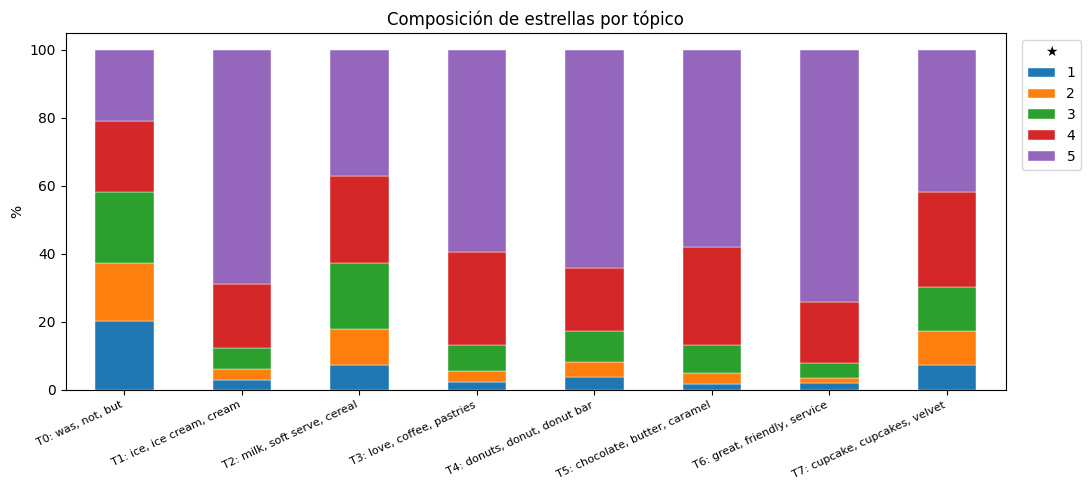

In [12]:
N_TOPICS = 8
nmf = NMF(n_components=N_TOPICS, random_state=42, init="nndsvda", max_iter=400)
W = nmf.fit_transform(X_tfidf_ngram)     # documentos x tópicos
H = nmf.components_                       # tópicos x términos
 
terminos = tfidf_ngram_vec.get_feature_names_out()
print("Tópicos encontrados (top 10 términos c/u):\n")
topic_labels = []
for k in range(N_TOPICS):
    top_idx = H[k].argsort()[::-1][:10]
    palabras = [terminos[i] for i in top_idx]
    topic_labels.append(", ".join(palabras[:3]))
    print(f"Tópico {k} [{topic_labels[k]}]:")
    print(f"  {', '.join(palabras)}")
 
yelp_df["topico_dominante"] = W.argmax(axis=1)
 
# Cruce tópico x rating: qué tema predice mejor la insatisfacción
cruce = pd.crosstab(yelp_df["topico_dominante"], yelp_df["Rating"], normalize="index") * 100
cruce.index = [f"T{k}: {topic_labels[k]}" for k in cruce.index]
print("\nComposición de estrellas por tópico dominante (%):")
print(cruce.round(1).to_string())
 
fig, ax = plt.subplots(figsize=(11, 5))
cruce.plot(kind="bar", stacked=True, ax=ax, edgecolor="white", linewidth=.3)
ax.set_title("Composición de estrellas por tópico"); ax.set_ylabel("%")
ax.legend(title="★", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=25, ha="right", fontsize=8)
plt.tight_layout(); plt.show()

### Interpretación de los tópicos

Los tópicos dominantes reflejan productos y experiencias concretas del corpus: helado, sabores, café y pastelería, donuts, chocolate y servicio. El tópico **T6**, asociado a `great`, `friendly` y `service`, concentra un **74,2 % de reseñas de 5 estrellas**, mientras que **T0**, caracterizado por `was`, `not` y `but`, presenta una distribución mucho más equilibrada y mayor presencia de ratings bajos.

Los tópicos relacionados con productos específicos, como `ice cream` o `donut`, también están dominados por valoraciones de 5 estrellas. Esto puede reflejar una experiencia positiva, pero también la composición del corpus; por ello, no debe interpretarse como efecto causal del tópico.

### 5.2. Aspectos de la experiencia del cliente

Además del sentimiento general, se identifican cinco dimensiones habituales de una visita a un restaurante: **comida**, **servicio**, **precio**, **espera** y **ambiente**.

El diccionario de términos ofrece una lectura rápida y transparente de qué reseñas mencionan cada aspecto. Para cada categoría se calcula:

- **Cobertura:** proporción de reseñas que la mencionan.
- **Rating medio con mención:** valoración de las reseñas que contienen el aspecto.
- **Diferencia:** cambio respecto a las reseñas que no lo mencionan.

Una diferencia negativa puede señalar un área de atención, pero no demuestra que el aspecto cause la insatisfacción. La cobertura debe tenerse en cuenta: una categoría poco frecuente ofrece menos evidencia para extraer conclusiones generales.


Cobertura de reseñas que mencionan cada aspecto:
comida      48.0
servicio    28.5
precio      20.0
espera      26.7
ambiente    14.0

Rating medio según se mencione el aspecto (ordenado por impacto):
 aspecto  rating_si_mencion  rating_no_mencion  diferencia
  precio              3.877              4.194      -0.317
  espera              4.009              4.175      -0.166
servicio              4.118              4.136      -0.018
  comida              4.165              4.099       0.067
ambiente              4.251              4.111       0.140


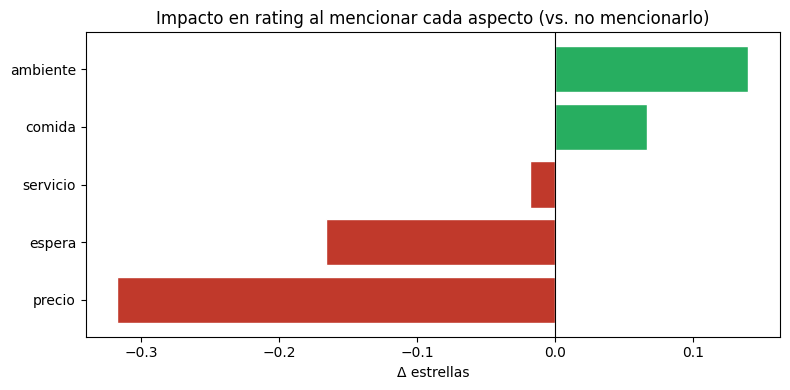


→ El aspecto con mayor Δ negativo es la palanca de negocio más clara:
  cuando aparece en la reseña, el rating cae más que con cualquier otro.


In [13]:
# En reseñas de restaurantes, reglas simples funcionan sorprendentemente bien.
ASPECTOS = {
    "comida":   ["food", "dish", "flavor", "taste", "delicious", "menu", "portion",
                 "meal", "pizza", "burger", "sauce", "fresh", "cook", "chef"],
    "servicio": ["service", "staff", "waiter", "waitress", "server", "rude",
                 "friendly", "attentive", "manager", "host"],
    "precio":   ["price", "expensive", "cheap", "worth", "value", "cost", "overpriced",
                 "affordable"],
    "espera":   ["wait", "slow", "quick", "fast", "line", "reservation", "minutes",
                 "hour", "long"],
    "ambiente": ["ambiance", "atmosphere", "decor", "noisy", "cozy", "clean", "dirty",
                 "music", "seating", "crowded"],
}
 
def marcar_aspectos(tokens):
    presentes = set()
    tset = set(tokens)
    for aspecto, palabras in ASPECTOS.items():
        if tset & set(palabras):
            presentes.add(aspecto)
    return presentes
 
yelp_df["aspectos"] = yelp_df["tokens"].map(marcar_aspectos)
for aspecto in ASPECTOS:
    yelp_df[f"asp_{aspecto}"] = yelp_df["aspectos"].map(lambda s: aspecto in s)
 
cobertura_aspectos = {a: yelp_df[f"asp_{a}"].mean() for a in ASPECTOS}
print("\nCobertura de reseñas que mencionan cada aspecto:")
print(pd.Series(cobertura_aspectos).mul(100).round(1).to_string())
 
# Rating medio condicionado a mencionar (o no) cada aspecto
filas = []
for a in ASPECTOS:
    con = yelp_df.loc[yelp_df[f"asp_{a}"], "Rating"].mean()
    sin = yelp_df.loc[~yelp_df[f"asp_{a}"], "Rating"].mean()
    filas.append((a, con, sin, con - sin))
tabla_aspectos = pd.DataFrame(filas, columns=["aspecto", "rating_si_mencion",
                                               "rating_no_mencion", "diferencia"])
tabla_aspectos = tabla_aspectos.sort_values("diferencia")
print("\nRating medio según se mencione el aspecto (ordenado por impacto):")
print(tabla_aspectos.round(3).to_string(index=False))
 
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#c0392b" if v < 0 else "#27ae60" for v in tabla_aspectos["diferencia"]]
ax.barh(tabla_aspectos["aspecto"], tabla_aspectos["diferencia"], color=colores, edgecolor="white")
ax.axvline(0, color="black", lw=.8)
ax.set_title("Impacto en rating al mencionar cada aspecto (vs. no mencionarlo)")
ax.set_xlabel("Δ estrellas"); plt.tight_layout(); plt.show()
 
print("\n→ El aspecto con mayor Δ negativo es la palanca de negocio más clara:\n"
      "  cuando aparece en la reseña, el rating cae más que con cualquier otro.")

### Interpretación de los aspectos

La **comida** es el aspecto más mencionado, con una cobertura del **48,0 %**, seguida del servicio (**28,5 %**) y la espera (**26,7 %**). El precio aparece en el 20,0 % de las reseñas y el ambiente en el 14,0 %.

El **precio** presenta la mayor diferencia negativa: las reseñas que lo mencionan tienen un rating medio de **3,877**, frente a **4,194** entre las que no lo mencionan, una diferencia de **-0,317 estrellas**. La espera también se relaciona con una valoración menor (**-0,166**). En cambio, ambiente (**+0,140**) y comida (**+0,067**) aparecen asociados a ratings ligeramente superiores.

Estas diferencias describen asociaciones, no impactos causales. En particular, mencionar un aspecto puede significar tanto una experiencia positiva como una queja; un análisis más preciso debería estudiar también el sentimiento específico de cada aspecto.

In [14]:
yelp_df_guardar = yelp_df.drop(columns=["aspectos"])
yelp_df_guardar.to_parquet("data/yelp_enriquecido.parquet")
np.save("data/embeddings_oracion.npy", X_embeddings)

print(f"Guardado: {len(yelp_df_guardar)} filas, {yelp_df_guardar.shape[1]} columnas")
print(f"Embeddings: {X_embeddings.shape}")

assert len(yelp_df_guardar) == len(X_embeddings), "Desalineados: revisar orden"
print("Alineación verificada: OK")

Guardado: 19894 filas, 34 columnas
Embeddings: (19894, 384)
Alineación verificada: OK


## 6. Lectura integrada y siguientes pasos

Cada técnica responde a una pregunta diferente:

| Técnica | Pregunta principal |
| --- | --- |
| TF-IDF y n-gramas | ¿Qué vocabulario distingue las reseñas? |
| VADER | ¿Qué polaridad expresa el texto? |
| Similitud | ¿Qué reseñas se parecen o se repiten? |
| NMF | ¿Qué temas aparecen en el corpus? |
| Aspectos | ¿Qué dimensiones de la experiencia se mencionan? |

### Límites de interpretación

- La distribución de ratings puede estar desbalanceada; una métrica global podría ocultar el comportamiento de las clases minoritarias.
- Las asociaciones entre palabras, tópicos, aspectos y estrellas no prueban causalidad.
- Las reglas y diccionarios requieren validación mediante revisión manual o anotación.

### Siguientes pasos

Para continuar el proyecto, se compararán modelos supervisados con distintas representaciones (TF-IDF, TF-IDF con bigramas, embeddings de oración) sobre 5 clases (1-5★). La partición train/test será aleatoria y estratificada por clase, para asegurar representación estable de las clases minoritarias (2★, 3★) en cada partición.